### 1) Data
- 데이터는 일자 및 서비스 별 방문자 수가 존제
- bnft_user_cnt: 유저의 행동에 따라 리워드를 지급하는 혜택성 지면 (마이데이터 가입시 n원, 보험 상품 조회시 n원 등)
- lck_comp_user_cnt: 유저의 보험료와 보장 데이터를 활용하여 가입한 보험의 가성비를 평가해주는 지면
- bridge_user_cnt: 외부 채널에서 유저의 보험 가입을 위한 마케팅을 할 때, 유저를 랜딩 시키는 브릿지 화면. 버튼을 누르는 즉시 보험 가입 페이지로 이동하며 보험 가입을 완료하면 리워드를 받을 수 있는 혜택성 지면
- detail_user_cnt: 유저의 보험 정보를 조회할 수 있는 정보성 지면 (보험료, 보장내역, 가입정보 등)
- r_fee_user_cnt: 유저의 보험금을 보험 대리점을 통해 청구할 수 있는 보험금 간편 청구 서비스 지면
- cm_user_cnt: 보험 가입 지면 (종속변수)

In [16]:
import shap
import xgboost

from sklearn import preprocessing
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [17]:
df = pd.read_csv('/Users/jangjuyeong/Documents/메타코드(spyder)/금융데이터분석_강의자료_메타코드M/data/bootcamp_chapter3-3_data.csv')

In [18]:
df

,partition_day,bnft_user_cnt,lck_comp_user_cnt,bridge_user_cnt,detail_user_cnt,r_fee_user_cnt,cm_user_cnt
0,2023-07-01,1626,71,4464,82,29,489
1,2023-07-02,1959,86,4882,466,37,525
2,2023-07-03,1360,12,1245,494,42,473
3,2023-07-04,1794,79,4247,228,10,501
4,2023-07-05,1630,81,4110,476,48,515
...,...,...,...,...,...,...,...
179,2023-12-27,689,36,2687,50,23,444
180,2023-12-28,1748,11,2931,436,25,502
181,2023-12-29,1908,99,3737,397,9,511
182,2023-12-30,1900,26,4746,239,22,506


In [19]:
#모델링
exp_v = df.iloc[:, 1:6]
tar_v = df[['cm_user_cnt']]

shap.initjs()

model = xgboost.XGBRFRegressor().fit(exp_v, tar_v)

explainer = shap.Explainer(model)
shap_value = explainer(exp_v)

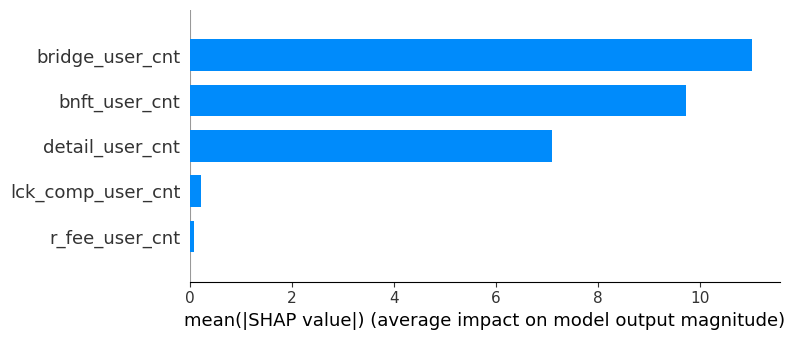

In [20]:
#기여도(중요도) 차팅
shap.summary_plot(shap_value, exp_v, plot_type='bar')

중요도: 브릿지(혜택성) 화면 -> 베네핏(혜택성) 화면 -> 디테일(정보성) 화면

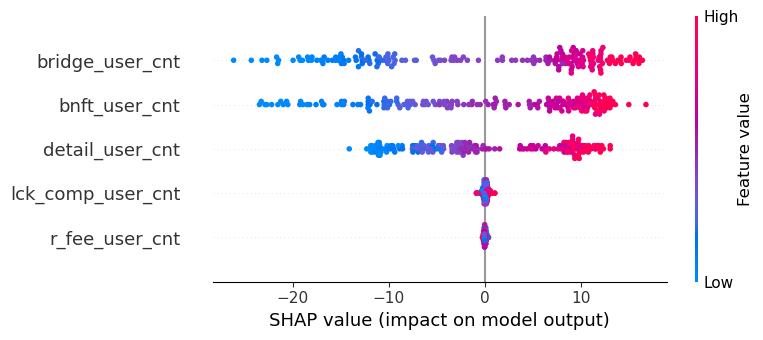

In [21]:
#변수별 shap value 차팅
shap.summary_plot(shap_value, exp_v)

- 모든 화면 노출수가 보험가입 유저수에 있어 양의 상관관계를 지닌다  
- 브릿지, 베네핏, 디테일 화면 순으로 그 영향도가 크다

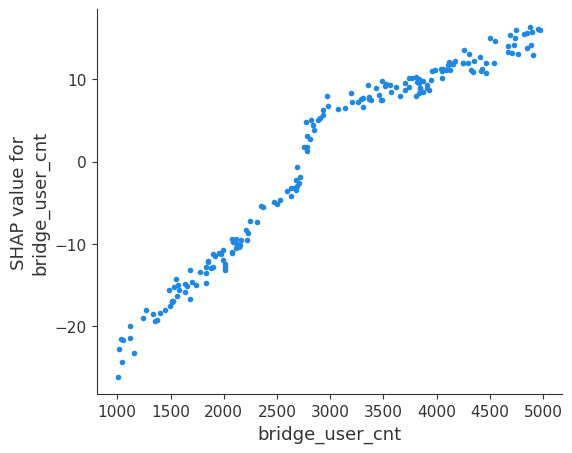

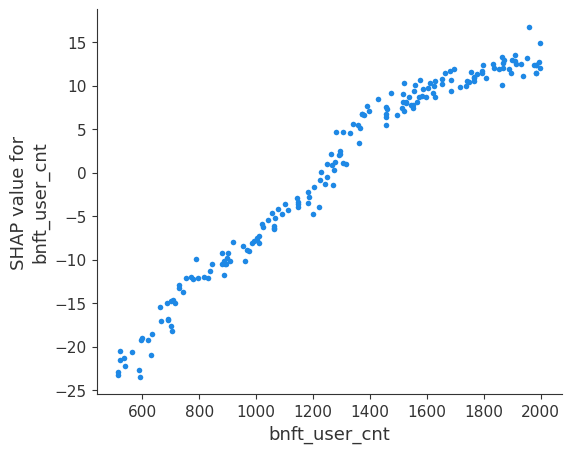

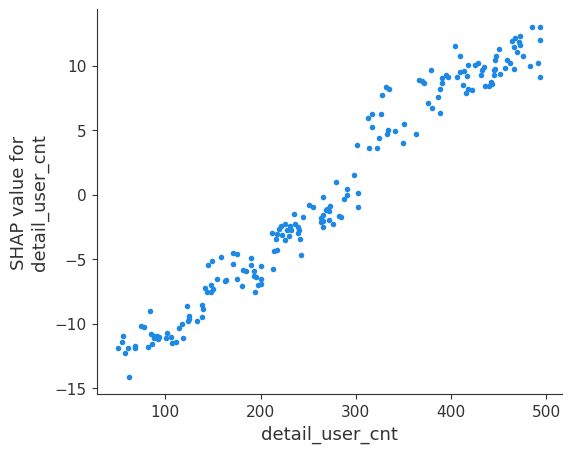

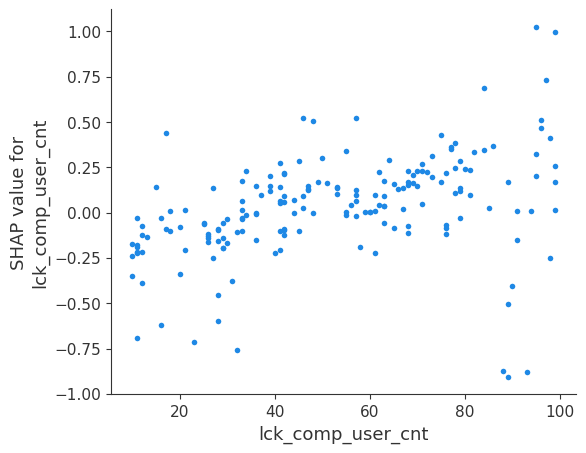

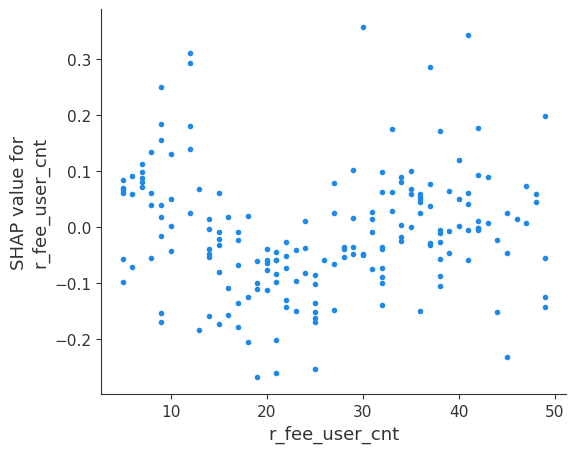

In [22]:
#Dependence Plot 차팅
top_inds = np.argsort(-np.sum(np.abs(shap_value.values), 0))

for i in range(5):
    shap.dependence_plot(top_inds[i], shap_value.values, exp_v, interaction_index=None)

- 혜택성 화면에는 성장체감이 보였다. 
- 반면에 정보성 화면(디테일 화면)에는 성장체감이 덜했다. 
- 그러므로 정보성 화면을 우리 제품의 전면에 내세우는 것이 적절한 의사결정으로 보인다. 

#### 워터폴 차팅

In [23]:
#가장 성과가 좋은 날, 나쁜 날의 Index 값
max_index = df[df['cm_user_cnt']==df['cm_user_cnt'].max()]['partition_day'].index[0]
min_index = df[df['cm_user_cnt']==df['cm_user_cnt'].min()]['partition_day'].index[0]

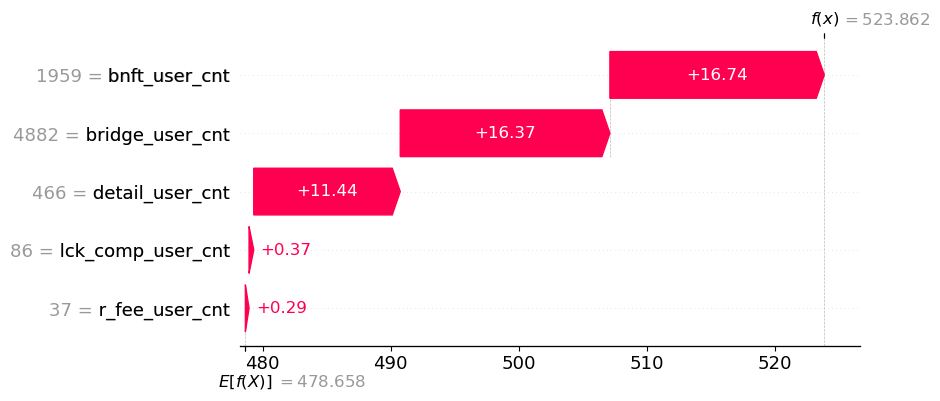

In [24]:
#가장 성과가 좋은 날 Water Fall
shap.plots.waterfall(shap_value[max_index])

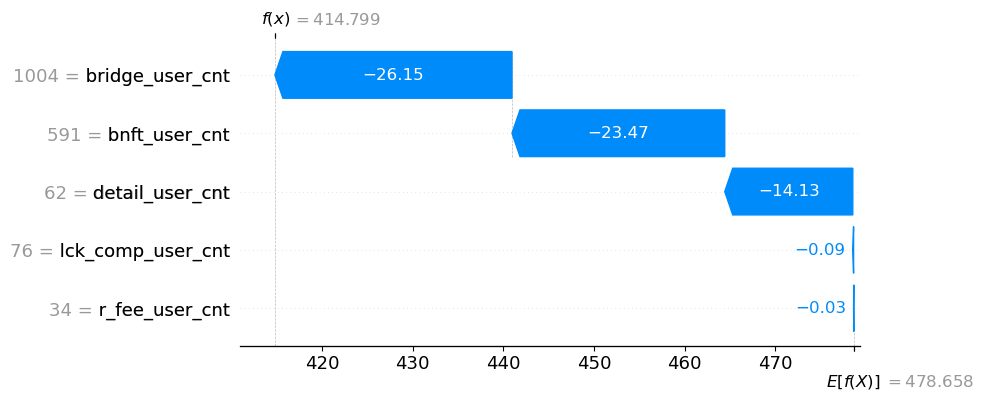

In [25]:
#가장 성과가 나쁜 날 Water Fall
shap.plots.waterfall(shap_value[min_index])